# House Price Prediction — Ames Housing Dataset

Predicts residential house sale prices using the Ames Housing dataset
(Kaggle: *House Prices - Advanced Regression Techniques*).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)

## 1. Load data

Update the paths below if your `train.csv` / `test.csv` files live somewhere other than `data/`.

In [3]:
from google.colab import files
uploaded = files.upload()  # lets you pick train.csv and test.csv from your computer

Saving test.csv to test.csv
Saving train.csv to train.csv


In [4]:
import os
os.makedirs("data", exist_ok=True)
os.rename("train.csv", "data/train.csv")
os.rename("test.csv", "data/test.csv")

train_df, test_df = load_data()  # now works with default paths

In [5]:
def load_data(train_path="data/train.csv", test_path="data/test.csv"):
    train_df = pd.read_csv(train_path)
    test_df = pd.read_csv(test_path)
    return train_df, test_df

train_df, test_df = load_data()
print("train shape:", train_df.shape)
print("test shape :", test_df.shape)
train_df.head()

train shape: (1460, 81)
test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,...,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,...,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,...,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,...,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,...,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,...,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Exploratory data analysis

Before engineering features, it's worth understanding what's actually in the
data: how the target is distributed, which columns have missing values, and
which numeric features correlate most strongly with `SalePrice`.

### 2.1 Target distribution

`SalePrice` is typically right-skewed — a few very expensive houses pull the mean up. Linear models tend to do better on a log-transformed target.

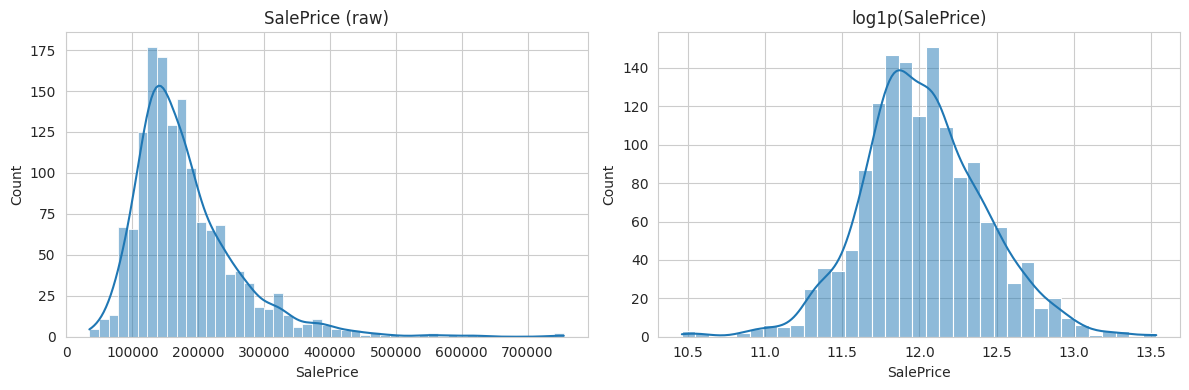

Skewness (raw)      : 1.883
Skewness (log1p)    : 0.121


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(train_df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("SalePrice (raw)")

sns.histplot(np.log1p(train_df["SalePrice"]), kde=True, ax=axes[1])
axes[1].set_title("log1p(SalePrice)")

plt.tight_layout()
plt.savefig("saleprice_distribution.png", dpi=150)
plt.show()

print("Skewness (raw)      :", train_df["SalePrice"].skew().round(3))
print("Skewness (log1p)    :", np.log1p(train_df["SalePrice"]).skew().round(3))

### 2.2 Missing values

Columns with a lot of missing data need a deliberate strategy (impute, drop, or treat 'missing' as its own category).

              missing_count  missing_pct
PoolQC                 1453         99.5
MiscFeature            1406         96.3
Alley                  1369         93.8
Fence                  1179         80.8
MasVnrType              872         59.7
FireplaceQu             690         47.3
LotFrontage             259         17.7
GarageType               81          5.5
GarageYrBlt              81          5.5
GarageFinish             81          5.5
GarageQual               81          5.5
GarageCond               81          5.5
BsmtExposure             38          2.6
BsmtFinType2             38          2.6
BsmtQual                 37          2.5
BsmtCond                 37          2.5
BsmtFinType1             37          2.5
MasVnrArea                8          0.5
Electrical                1          0.1


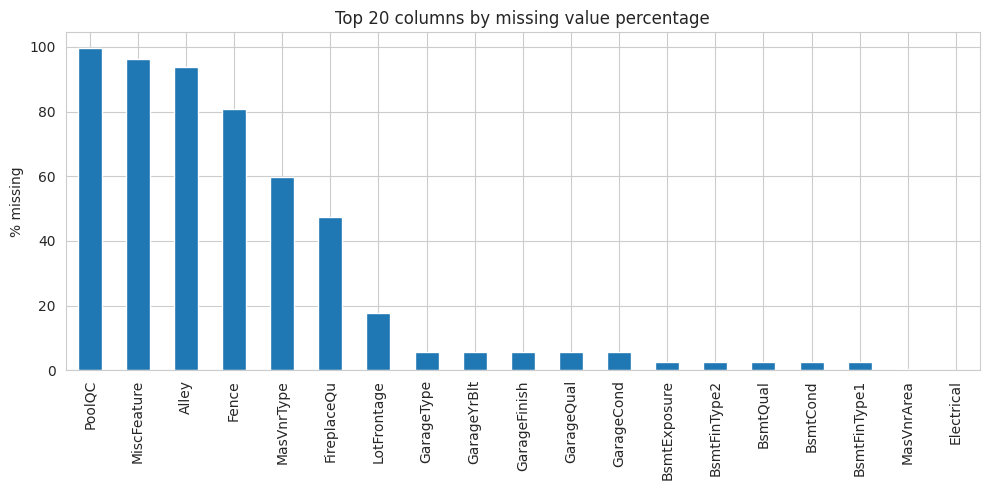

In [7]:
missing = train_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train_df) * 100).round(1)

missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_summary.head(20))

plt.figure(figsize=(10, 5))
missing_summary.head(20)["missing_pct"].plot(kind="bar")
plt.ylabel("% missing")
plt.title("Top 20 columns by missing value percentage")
plt.tight_layout()
plt.savefig("missing_values.png", dpi=150)
plt.show()

### 2.3 Correlation with SalePrice

Which numeric features are most linearly related to the target? This guides which features are worth engineering / keeping.

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


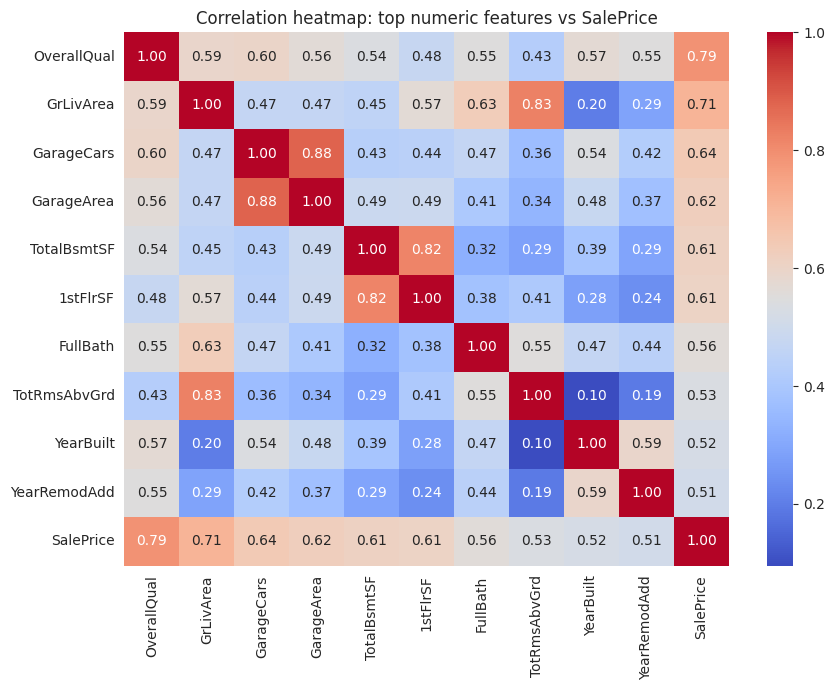

In [8]:
numeric_df = train_df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
print(corr_with_target.head(15))

top_features = corr_with_target.index[1:11]  # skip SalePrice itself
plt.figure(figsize=(9, 7))
sns.heatmap(
    train_df[top_features.tolist() + ["SalePrice"]].corr(),
    annot=True, fmt=".2f", cmap="coolwarm"
)
plt.title("Correlation heatmap: top numeric features vs SalePrice")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()

## 3. Feature engineering

The original version used only `TotalSF`, `Bedrooms`, and `TotalBathrooms`.
Here we add several more features that the EDA above (and domain knowledge
about house prices) suggest matter: overall quality, house age, garage
capacity, lot size, and neighborhood.

In [9]:
NUMERIC_FEATURES = [
    "TotalSF",          # engineered: basement + 1st + 2nd floor sqft
    "TotalBathrooms",   # engineered: full + half baths (basement included)
    "Bedrooms",
    "OverallQual",       # 1-10 overall material/finish quality
    "OverallCond",       # 1-10 overall condition
    "HouseAge",          # engineered: YrSold - YearBuilt
    "YearsSinceRemodel", # engineered: YrSold - YearRemodAdd
    "GarageCars",
    "LotArea",
    "Fireplaces",
]

CATEGORICAL_FEATURES = [
    "Neighborhood",
]

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def engineer_features(df):
    """Build the feature set the models will use."""
    df = df.copy()

    # Total living area = basement + 1st floor + 2nd floor square footage
    df["TotalSF"] = (
        df["TotalBsmtSF"].fillna(0)
        + df["1stFlrSF"].fillna(0)
        + df["2ndFlrSF"].fillna(0)
    )

    # Combine full and half baths (half bath counts as 0.5)
    df["TotalBathrooms"] = (
        df["FullBath"].fillna(0)
        + 0.5 * df["HalfBath"].fillna(0)
        + df["BsmtFullBath"].fillna(0)
        + 0.5 * df["BsmtHalfBath"].fillna(0)
    )

    df["Bedrooms"] = df["BedroomAbvGr"].fillna(0)

    # House age and time since remodel at time of sale
    df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
    df["YearsSinceRemodel"] = df["YrSold"] - df["YearRemodAdd"]

    # A few columns can have small numbers of missing values in test.csv
    df["GarageCars"] = df["GarageCars"].fillna(0)
    df["LotArea"] = df["LotArea"].fillna(df["LotArea"].median())
    df["Fireplaces"] = df["Fireplaces"].fillna(0)
    df["OverallQual"] = df["OverallQual"].fillna(df["OverallQual"].median())
    df["OverallCond"] = df["OverallCond"].fillna(df["OverallCond"].median())
    df["Neighborhood"] = df["Neighborhood"].fillna("Unknown")

    return df[ALL_FEATURES]

## 4. Preprocessing pipeline

Numeric features are scaled and categorical features (just `Neighborhood`
here) are one-hot encoded. Wrapping this in a `ColumnTransformer` +
`Pipeline` means the exact same preprocessing is applied consistently to
train, validation, and test data — no risk of leakage or mismatched
columns.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

## 5. Train and compare models

Instead of a single train/val split, we use 5-fold cross-validation for a
more reliable estimate of generalization error, and we compare three models:

- **Linear Regression** (the original baseline)
- **Ridge Regression** (L2-regularized — often more robust with many features)
- **Random Forest** (a non-linear benchmark)

The target is log-transformed (`log1p`) before fitting, and predictions are
converted back with `expm1` before computing metrics, so RMSE/MAE stay in
dollar terms.

In [11]:
def build_model(estimator):
    return Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", estimator),
    ])


def cross_validate_models(train_df, n_splits=5, random_state=42):
    X = engineer_features(train_df)
    y_log = np.log1p(train_df["SalePrice"])

    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    candidates = {
        "LinearRegression": LinearRegression(),
        "Ridge": Ridge(alpha=10.0),
        "RandomForest": RandomForestRegressor(
            n_estimators=300, max_depth=12, random_state=random_state, n_jobs=-1
        ),
    }

    results = {}
    for name, estimator in candidates.items():
        pipeline = build_model(estimator)
        # scoring on log target; convert neg-MSE -> RMSE for readability
        neg_mse_scores = cross_val_score(
            pipeline, X, y_log, cv=kfold, scoring="neg_mean_squared_error"
        )
        rmse_log = np.sqrt(-neg_mse_scores)
        r2_scores = cross_val_score(pipeline, X, y_log, cv=kfold, scoring="r2")

        results[name] = {"rmse_log_mean": rmse_log.mean(), "rmse_log_std": rmse_log.std(),
                          "r2_mean": r2_scores.mean(), "r2_std": r2_scores.std()}

        print(f"{name:16s}  RMSE(log): {rmse_log.mean():.4f} (+/- {rmse_log.std():.4f})"
              f"   R^2: {r2_scores.mean():.4f} (+/- {r2_scores.std():.4f})")

    return results


cv_results = cross_validate_models(train_df)

LinearRegression  RMSE(log): 0.1506 (+/- 0.0329)   R^2: 0.8450 (+/- 0.0880)
Ridge             RMSE(log): 0.1513 (+/- 0.0352)   R^2: 0.8426 (+/- 0.0941)
RandomForest      RMSE(log): 0.1434 (+/- 0.0189)   R^2: 0.8662 (+/- 0.0444)


## 6. Fit the best model on a held-out validation split

Cross-validation tells us which model generalizes best on average; here we
fit that model on a single train/val split so we can inspect predictions,
residuals, and coefficients concretely. Swap `chosen_model` below if a
different candidate wins on your data.

In [12]:
def train_and_evaluate(train_df, estimator, test_size=0.2, random_state=42):
    X = engineer_features(train_df)
    y_log = np.log1p(train_df["SalePrice"])

    X_train, X_val, y_train_log, y_val_log = train_test_split(
        X, y_log, test_size=test_size, random_state=random_state
    )

    pipeline = build_model(estimator)
    pipeline.fit(X_train, y_train_log)

    val_pred_log = pipeline.predict(X_val)

    # Convert back to dollar scale for interpretable metrics
    y_val = np.expm1(y_val_log)
    val_predictions = np.expm1(val_pred_log)

    rmse = np.sqrt(mean_squared_error(y_val, val_predictions))
    mae = mean_absolute_error(y_val, val_predictions)
    r2 = r2_score(y_val, val_predictions)

    print("Validation performance (dollar scale)")
    print(f"  RMSE : {rmse:,.2f}")
    print(f"  MAE  : {mae:,.2f}")
    print(f"  R^2  : {r2:.4f}")

    return pipeline, X_val, y_val, val_predictions


# Pick the model with the best CV R^2 from the results above.
# RandomForest and Ridge are common winners over plain LinearRegression here;
# change this if your cross-validation results point elsewhere.
chosen_estimator = Ridge(alpha=10.0)

model, X_val, y_val, val_predictions = train_and_evaluate(train_df, chosen_estimator)

Validation performance (dollar scale)
  RMSE : 28,955.49
  MAE  : 18,098.36
  R^2  : 0.8907


## 7. Inspect feature importance / coefficients

For linear models this shows standardized coefficients (comparable because
numeric features were scaled). For Random Forest, swap in `.feature_importances_`.

Top 15 features by |coefficient| (log-target, standardized inputs):
cat__Neighborhood_BrDale    -0.117485
cat__Neighborhood_StoneBr    0.114491
num__OverallQual             0.103012
cat__Neighborhood_Crawfor    0.100429
cat__Neighborhood_NridgHt    0.093792
cat__Neighborhood_MeadowV   -0.091831
num__TotalSF                 0.091598
cat__Neighborhood_NoRidge    0.079547
cat__Neighborhood_ClearCr    0.075536
num__GarageCars              0.064339
num__HouseAge               -0.062884
cat__Neighborhood_Edwards   -0.059164
cat__Neighborhood_OldTown   -0.053760
num__OverallCond             0.052616
cat__Neighborhood_IDOTRR    -0.052542
dtype: float64


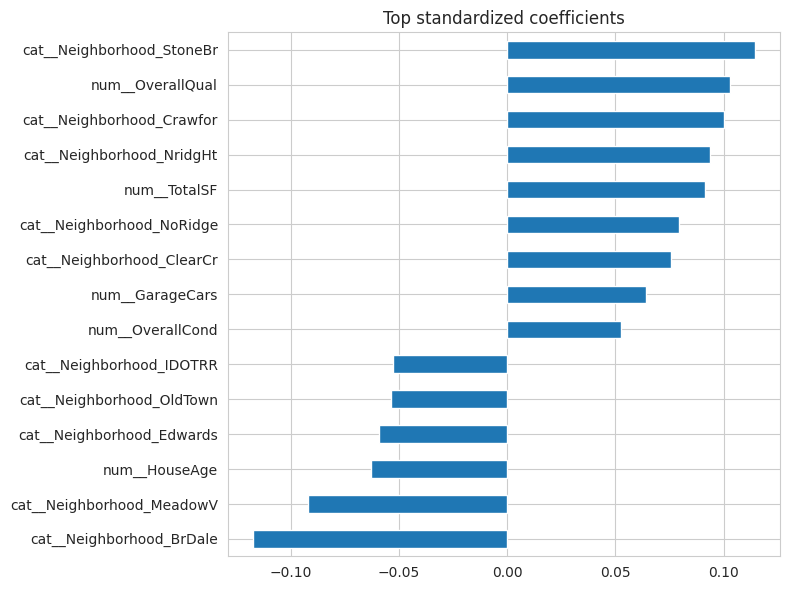

In [13]:
def show_linear_coefficients(pipeline):
    model_step = pipeline.named_steps["model"]
    if not hasattr(model_step, "coef_"):
        print("Chosen estimator does not expose linear coefficients "
              "(e.g. it's a tree-based model) - skipping this view.")
        return

    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
    coefs = pd.Series(model_step.coef_, index=feature_names).sort_values(key=abs, ascending=False)

    print("Top 15 features by |coefficient| (log-target, standardized inputs):")
    print(coefs.head(15))

    plt.figure(figsize=(8, 6))
    coefs.head(15).sort_values().plot(kind="barh")
    plt.title("Top standardized coefficients")
    plt.tight_layout()
    plt.savefig("feature_coefficients.png", dpi=150)
    plt.show()


show_linear_coefficients(model)

## 8. Plot actual vs. predicted prices

Saved plot to actual_vs_predicted.png


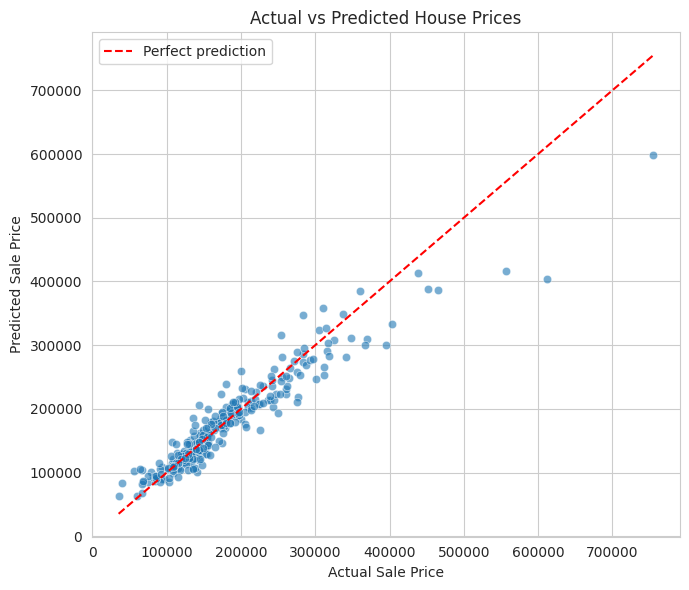

In [14]:
def plot_predictions(y_val, val_predictions):
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_val, y=val_predictions, alpha=0.6)
    lims = [min(y_val.min(), val_predictions.min()), max(y_val.max(), val_predictions.max())]
    plt.plot(lims, lims, "r--", label="Perfect prediction")
    plt.xlabel("Actual Sale Price")
    plt.ylabel("Predicted Sale Price")
    plt.title("Actual vs Predicted House Prices")
    plt.legend()
    plt.tight_layout()
    plt.savefig("actual_vs_predicted.png", dpi=150)
    print("Saved plot to actual_vs_predicted.png")
    plt.show()


plot_predictions(y_val, val_predictions)

## 9. Residual diagnostics

A pure actual-vs-predicted plot can hide systematic bias. A residual plot
(errors vs. predicted value) makes it easier to spot patterns — e.g. the
model consistently underpricing expensive homes.

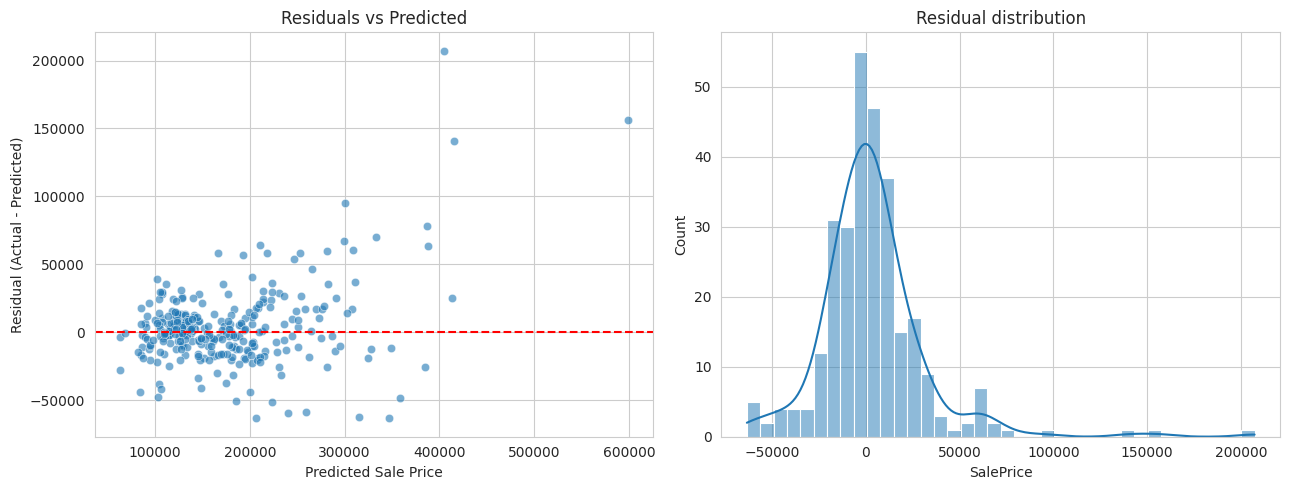

Mean residual: 3,358.86  (should be close to 0)


In [15]:
def plot_residuals(y_val, val_predictions):
    residuals = y_val - val_predictions

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.scatterplot(x=val_predictions, y=residuals, alpha=0.6, ax=axes[0])
    axes[0].axhline(0, color="red", linestyle="--")
    axes[0].set_xlabel("Predicted Sale Price")
    axes[0].set_ylabel("Residual (Actual - Predicted)")
    axes[0].set_title("Residuals vs Predicted")

    sns.histplot(residuals, kde=True, ax=axes[1])
    axes[1].set_title("Residual distribution")

    plt.tight_layout()
    plt.savefig("residuals.png", dpi=150)
    plt.show()

    print(f"Mean residual: {residuals.mean():,.2f}  (should be close to 0)")


plot_residuals(y_val, val_predictions)

## 10. Refit on all training data and generate submission

Once you're happy with the chosen model, refit it on the *full* training set
(not just the 80% split) before predicting on the test set — this squeezes
out a bit more performance since no data is held back.

In [16]:
def generate_submission(train_df, test_df, estimator, out_path="submission.csv"):
    X_train_full = engineer_features(train_df)
    y_train_full_log = np.log1p(train_df["SalePrice"])

    pipeline = build_model(estimator)
    pipeline.fit(X_train_full, y_train_full_log)

    X_test = engineer_features(test_df)
    pred_log = pipeline.predict(X_test)
    predictions = np.expm1(pred_log)  # back to dollar scale

    submission = pd.DataFrame({"Id": test_df["Id"], "SalePrice": predictions})
    submission.to_csv(out_path, index=False)
    print(f"Saved predictions to {out_path}")
    return submission


submission_df = generate_submission(train_df, test_df, chosen_estimator)
submission_df.head()

Saved predictions to submission.csv


,Id,SalePrice
0,1461,111658.903165
1,1462,141198.574043
2,1463,166490.195624
3,1464,187371.203240
4,1465,207039.276087


## Next steps / ideas for further improvement

- Add more categorical features (`ExterQual`, `KitchenQual`, `BsmtQual`) with ordinal encoding
- Try `GradientBoostingRegressor` or `XGBoost`/`LightGBM` for stronger non-linear performance
- Tune hyperparameters (`alpha` for Ridge, `max_depth`/`n_estimators` for the forest) with `GridSearchCV`
- Handle outliers (e.g. the well-known `GrLivArea` outliers in this dataset)
- Ensemble multiple models (simple averaging or stacking) for a final boost